In [2]:
# === Decision boundary plotting from a run folder (α vs β) ===
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [3]:
# --- Decision boundary plotting cell (now uses Dataset.split_census_income and overlays best_synthetic.csv) ---

import os, json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

# Your project imports
from agents.ffnn_agent2 import FFNNAgent      # agent wrapper (model outputs [N,2] logits)
from dataset import Dataset                   # <-- NEW: use this to reconstruct splits when needed

# ----------------------------
# Helpers for files & loading
# ----------------------------
def _is_seed_dir(path: str) -> bool:
    return (
        os.path.isdir(path)
        and os.path.isfile(os.path.join(path, "metrics.csv"))
        and os.path.isfile(os.path.join(path, "meta.json"))
    )

def _find_seed_dir(run_dir: str) -> str:
    run_dir = os.path.abspath(run_dir.rstrip("/"))
    if _is_seed_dir(run_dir):
        return run_dir
    seed_dirs = sorted([os.path.join(run_dir, d) for d in os.listdir(run_dir) if d.startswith("seed_")])
    seed_dirs = [sd for sd in seed_dirs if _is_seed_dir(sd)]
    if len(seed_dirs) == 1:
        return seed_dirs[0]
    if len(seed_dirs) > 1:
        print(f"[info] Experiment root with multiple seeds; using first: {os.path.basename(seed_dirs[0])}")
        return seed_dirs[0]
    raise FileNotFoundError("Could not locate a valid seed directory under: " + run_dir)

def _read_json(path: Path) -> dict:
    try:
        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
    except Exception:
        pass
    return {}

def _maybe_to_numpy(x):
    if torch is not None and isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def _try_load_array(run_dir: str, base_names):
    """
    Try several common filenames (npy/npz/pt/csv) for arrays.
    Returns ndarray or None.
    """
    candidates = []
    for name in base_names:
        candidates += glob.glob(os.path.join(run_dir, name))
    for p in candidates:
        ext = os.path.splitext(p)[1].lower()
        try:
            if ext == ".npy":
                return np.load(p)
            elif ext == ".npz":
                with np.load(p) as npz:
                    return npz[list(npz.files)[0]]
            elif ext == ".csv":
                return pd.read_csv(p).values
            elif ext in (".pt", ".pth"):
                arr = torch.load(p, map_location="cpu")
                if isinstance(arr, dict):
                    for k in ("x", "X", "data", "array", "x_test", "y_test"):
                        if k in arr:
                            arr = arr[k]
                            break
                return _maybe_to_numpy(arr)
        except Exception as e:
            print(f"[warn] failed to load {p}: {e}")
    return None

def _load_data_arrays(seed_dir: str):
    """
    Tries to load x_test, y_test, x_train, y_train from common filenames in the seed dir.
    Returns (x_test, y_test, x_train, y_train) as ndarrays or None.
    Expected shape for x_* is [N, 2] (already PCA'd).
    """
    x_test = _try_load_array(seed_dir, ["x_test.npy", "X_test.npy", "x_test.pt", "test_x.npy", "test.npz", "test.pt"])
    y_test = _try_load_array(seed_dir, ["y_test.npy", "Y_test.npy", "y_test.pt", "test_y.npy"])
    x_train = _try_load_array(seed_dir, ["x_train.npy", "X_train.npy", "x_train.pt", "train_x.npy", "train.npz", "train.pt"])
    y_train = _try_load_array(seed_dir, ["y_train.npy", "Y_train.npy", "y_train.pt", "train_y.npy"])
    return x_test, y_test, x_train, y_train

# ---------------------------------------
# State dict remapping & agent rehydration
# ---------------------------------------
def _detect_model_prefix(model: nn.Module) -> str:
    for k in model.state_dict().keys():
        return k.split(".", 1)[0]
    return "net"

def _remap_prefix(state_dict: dict, src_prefix: str, dst_prefix: str) -> dict:
    if src_prefix == dst_prefix:
        return state_dict
    remapped = {}
    src_head = src_prefix + "."
    dst_head = dst_prefix + "."
    for k, v in state_dict.items():
        if k.startswith(src_head):
            remapped[dst_head + k[len(src_head):]] = v
        else:
            remapped[k] = v
    return remapped

def _normalize_state_dict_to_model(state_path: Path, model: nn.Module) -> dict:
    sd = torch.load(state_path, map_location="cpu")
    if not isinstance(sd, dict):
        raise ValueError(f"Checkpoint at {state_path} is not a plain state_dict.")
    model_prefix = _detect_model_prefix(model)
    for src in ["network", "net"]:
        sd = _remap_prefix(sd, src, model_prefix)
    return sd

def _build_ffnn_config_from_meta(seed_dir: Path, default_device="cpu"):
    meta_path = seed_dir / "ffnn_meta.json"
    meta = _read_json(meta_path)
    cfg = {
        "input_size": int(meta.get("n_pca_components", 2)),
        "hidden_sizes": meta.get("hidden_sizes", [32, 16]),
        "output_size": meta.get("output_size", 2),
        "learning_rate": meta.get("learning_rate", 0.001),
        "batch_size": meta.get("batch_size", 32),
        "epochs": meta.get("epochs", 10),
        "type": meta.get("type", "classification"),
        "classes": meta.get("classes", [0, 1]),
        "device": default_device,
        "seed": meta.get("seed", 42),
    }
    return cfg, int(meta.get("n_pca_components", 2))

def _load_agent_from_ckpt(seed_dir: Path, ckpt_name: str, label: str):
    cfg, _ = _build_ffnn_config_from_meta(seed_dir, default_device="cpu")
    agent = FFNNAgent(**cfg)
    model = agent.model
    ckpt_path = seed_dir / ckpt_name
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")
    sd = _normalize_state_dict_to_model(ckpt_path, model)
    missing, unexpected = model.load_state_dict(sd, strict=False)
    if missing or unexpected:
        print(f"[warn] {label} load_state_dict mismatches — missing:{list(missing)} unexpected:{list(unexpected)}")
    else:
        print(f"[ok] {label} weights loaded from {ckpt_path.name}")
    return agent

# ---------------------------------------
# Meta + split reconstruction using Dataset
# ---------------------------------------
def _load_meta(seed_dir: str | Path) -> dict:
    seed_dir = Path(seed_dir)
    meta_path = seed_dir / "meta.json"
    if meta_path.exists():
        try:
            with open(meta_path, "r", encoding="utf-8") as f:
                return json.load(f)
        except Exception as e:
            print(f"[warn] failed reading {meta_path}: {e}")
    return {}

def _reconstruct_splits_from_meta(seed_dir: str | Path, meta: dict):
    """
    Recreate PCA(2D) θ_train/val/test splits using Dataset.split_census_income
    with the run's seed/bias/size config.
    Returns numpy arrays: (X_train, X_val, X_test, y_train, y_val, y_test).
    """
    # Fix: ensure random_state is int, not str, for sklearn compatibility
    seed      = int(meta.get("seed", 42))
    bias_pct  = float(meta.get("BIAS_PCT", 0.35))
    real_size = int(meta.get("REAL_DATA_SIZE", 3000))

    # Pass seed as int, not str, to Dataset so that train_test_split gets an int random_state
    ds = Dataset(dataset_name="census_income", seed=seed, device="cpu")
    Xtr, Xval, Xte, Ytr, Yval, Yte = ds.split_census_income(
        train_size=real_size, bias_pct=bias_pct, pca_components=2
    )

    to_np = lambda t: t.detach().cpu().numpy() if hasattr(t, "detach") else np.asarray(t)
    return tuple(to_np(x) for x in (Xtr, Xval, Xte, Ytr, Yval, Yte))

# ---------------------------------------
# Plotting
# ---------------------------------------
from matplotlib.lines import Line2D

def plot_decision_boundaries_for_run(
    run_dir: str,
    alpha_agent,
    beta_agent,
    f1_thresh: float = 0.5,
    grid_pad: float = 0.08,
    grid_res: int = 300,
    save_png: bool = True,
    *,
    show_both_correct: bool = False,
    show_both_wrong: bool = False,
    overlay_size: int = 50,
    overlay_alpha: float = 1.0,
    show_test_majority: bool = True,
    show_test_minority: bool = True,
    show_synth_minority: bool = True
):
    """
    Plot α vs β decision boundaries and Δp heatmap on 2D PCA space for a single run folder.
    Also overlays synthetic points from best_synthetic.csv (pca_0,pca_1,target) if present.

    Parameters
    ----------
    show_test_majority : bool
        If True, show test majority (y=0) points.
    show_test_minority : bool
        If True, show test minority (y=1) points.
    show_synth_minority : bool
        If True, show synthetic minority (y=1) points from best_synthetic.csv.
    """
    seed_dir = _find_seed_dir(run_dir)
    meta = _load_meta(seed_dir)

    # --- Load (or reconstruct) datasets ---
    x_test, y_test, x_train, y_train = _load_data_arrays(seed_dir)
    if x_test is None or y_test is None:
        print("[info] x_test/y_test not found; reconstructing via Dataset.split_census_income(...)")
        Xtr, Xval, Xte, Ytr, Yval, Yte = _reconstruct_splits_from_meta(seed_dir, meta)
        x_test, y_test, x_train, y_train = Xte, Yte, Xtr, Ytr

    x_test = np.asarray(x_test); y_test = np.asarray(y_test).astype(int).ravel()
    assert x_test.shape[1] == 2, f"x_test must be [N,2]; got {x_test.shape}"

    # --- Grid over extents (include only real data for extents; synthetic just overlays) ---
    all_X = x_test if x_train is None else np.vstack([x_train, x_test])
    xmin, ymin = all_X.min(axis=0); xmax, ymax = all_X.max(axis=0)
    x_range, y_range = xmax - xmin, ymax - ymin
    xmin -= grid_pad * x_range; xmax += grid_pad * x_range
    ymin -= grid_pad * y_range; ymax += grid_pad * y_range

    xx = np.linspace(xmin, xmax, grid_res)
    yy = np.linspace(ymin, ymax, grid_res)
    XX, YY = np.meshgrid(xx, yy)
    grid = np.c_[XX.ravel(), YY.ravel()]

    # --- Predict helpers ---
    def _p1(agent, Xnp):
        with torch.no_grad():
            X = torch.from_numpy(Xnp.astype(np.float32))
            logits = agent.model(X)
            return torch.softmax(logits, -1)[..., 1].cpu().numpy()

    p_alpha_grid = _p1(alpha_agent, grid).reshape(XX.shape)
    p_beta_grid  = _p1(beta_agent,  grid).reshape(XX.shape)
    delta_grid   = p_beta_grid - p_alpha_grid

    p_alpha_test = _p1(alpha_agent, x_test).ravel()
    p_beta_test  = _p1(beta_agent,  x_test).ravel()
    yhat_a = (p_alpha_test >= f1_thresh).astype(int)
    yhat_b = (p_beta_test  >= f1_thresh).astype(int)

    # Four outcome masks
    wins_mask     = (yhat_a != y_test) & (yhat_b == y_test)   # β fixes α
    losses_mask   = (yhat_a == y_test) & (yhat_b != y_test)   # β breaks α
    both_correct  = (yhat_a == y_test) & (yhat_b == y_test)
    both_wrong    = (yhat_a != y_test) & (yhat_b != y_test)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8.5, 7))

    vmax = float(np.nanmax(np.abs(delta_grid))) if np.isfinite(delta_grid).any() else 1.0
    im = ax.imshow(delta_grid, origin="lower",
                   extent=[xmin, xmax, ymin, ymax],
                   aspect="auto", alpha=0.65, vmin=-vmax, vmax=vmax)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Δp = pβ − pα")

    # Decision contours (proxies added to legend below)
    try:
        ax.contour(XX, YY, p_alpha_grid, levels=[f1_thresh],
                   linewidths=2, linestyles="--", colors=["black"])
    except Exception:
        pass
    try:
        ax.contour(XX, YY, p_beta_grid, levels=[f1_thresh],
                   linewidths=2, linestyles="-", colors=["black"])
    except Exception:
        pass

    # Test scatter (with toggles)
    if show_test_majority:
        ax.scatter(x_test[y_test==0, 0], x_test[y_test==0, 1], s=12, alpha=0.75, label="Test majority (y=0)")
    if show_test_minority:
        ax.scatter(x_test[y_test==1, 0], x_test[y_test==1, 1], s=12, alpha=0.75, label="Test minority (y=1)")

    # --- Overlay synthetic points from best_synthetic.csv (pca_0,pca_1,target) ---
    try:
        synth_csv = Path(seed_dir) / "best_synthetic.csv"
        if synth_csv.exists():
            df_s = pd.read_csv(synth_csv)
            if {"pca_0", "pca_1", "target"}.issubset(df_s.columns):
                Xs = df_s[["pca_0", "pca_1"]].to_numpy()
                ys = df_s["target"].to_numpy().astype(int).ravel()
                if (ys == 0).any():
                    ax.scatter(
                        Xs[ys == 0, 0], Xs[ys == 0, 1],
                        s=24, marker="^", facecolors="none", edgecolors="#6a5acd", linewidths=1.2,
                        alpha=0.95, label="Synthetic majority (y=0)"
                    )
                if show_synth_minority and (ys == 1).any():
                    ax.scatter(
                        Xs[ys == 1, 0], Xs[ys == 1, 1],
                        s=24, marker="^", alpha=0.95,
                        label="Synthetic minority (y=1)"
                    )
            else:
                print("[warn] best_synthetic.csv missing columns pca_0,pca_1,target; skipping overlay.")
        else:
            print("[info] No best_synthetic.csv found in seed dir; skipping synthetic overlay.")
    except Exception as e:
        print(f"[warn] Failed to overlay synthetic points: {e}")

    # Always-on overlays: β fixes α (green ring) / β breaks α (red ring)
    # Only show these overlays if at least one of show_test_majority or show_test_minority is True
    if show_test_majority or show_test_minority:
        if wins_mask.any():
            ax.scatter(x_test[wins_mask, 0], x_test[wins_mask, 1],
                       s=overlay_size, facecolors='none', edgecolors='green',
                       linewidths=1.6, alpha=overlay_alpha, label="β fixes α")
        if losses_mask.any():
            ax.scatter(x_test[losses_mask, 0], x_test[losses_mask, 1],
                       s=overlay_size, facecolors='none', edgecolors='red',
                       linewidths=1.6, alpha=overlay_alpha, label="β breaks α")

    # Optional overlays
    if show_both_correct and both_correct.any():
        ax.scatter(x_test[both_correct, 0], x_test[both_correct, 1],
                   s=overlay_size, facecolors='none', edgecolors='#00bcd4',
                   marker='D', linewidths=1.4, alpha=overlay_alpha, label="both correct")
    if show_both_wrong and both_wrong.any():
        ax.scatter(x_test[both_wrong, 0], x_test[both_wrong, 1],
                   s=overlay_size, c='black', marker='x',
                   linewidths=1.2, alpha=overlay_alpha, label="both wrong")

    # Proxies for contours so legend text is clear
    proxy_alpha = Line2D([0], [0], color="black", lw=2, ls="--", label="α boundary")
    proxy_beta  = Line2D([0], [0], color="black", lw=2, ls="-",  label="β boundary")

    handles, labels = ax.get_legend_handles_labels()
    handles = [proxy_alpha, proxy_beta] + handles
    labels  = [h.get_label() for h in [proxy_alpha, proxy_beta]] + labels

    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    exp_name = os.path.basename(os.path.dirname(seed_dir))
    seed_name = os.path.basename(seed_dir)
    ax.set_title(f"Decision Boundaries in PCA(2D)\nRun: {exp_name} / {seed_name}")
    ax.legend(handles, labels, loc="best", fontsize=9)
    ax.grid(alpha=0.2)
    plt.tight_layout()

    if save_png:
        out_png = os.path.join(seed_dir, "decision_boundary.png")
        plt.savefig(out_png, dpi=180)
        print(f"[info] Saved decision boundary plot → {out_png}")

    plt.show()


In [4]:
# ---- Usage ----
RUN_DIR = "training_runs/EP1000_TRJ2000_REAL3000_BIAS0.35_LS0.8-0.8_MODEgauss_nopen_TAU0.1_TS20250916201020_ba97a621/seed_999"
seed_dir = Path(_find_seed_dir(RUN_DIR))
# Build α/β agents from saved state dicts, remapping 'network.' -> model prefix if needed.
alpha_agent = _load_agent_from_ckpt(seed_dir, "alpha_state_dict.pt", label="Alpha")
beta_agent  = _load_agent_from_ckpt(seed_dir, "best_beta_state_dict.pt", label="Beta")

# Plot
plot_decision_boundaries_for_run(RUN_DIR, alpha_agent, beta_agent, f1_thresh=0.5, show_both_correct=False, show_both_wrong=False,     
    show_test_majority= True,
    show_test_minority= True,
    show_synth_minority= True)


# ---------------------------
# Dataset "promising" metrics
# ---------------------------
from sklearn.metrics import f1_score, brier_score_loss, average_precision_score

def analyze_dataset_promising_metrics(
    run_dir: str,
    alpha_agent,
    beta_agent,
    *,
    f1_thresh: float = 0.5,
    boundary_band: float = 0.08,   # how close to alpha's boundary counts as "near"
    grid_res: int = 300,
    grid_pad: float = 0.08,
    verbose: bool = True,
):
    """
    Compute diagnostics that indicate whether a dataset setup is *promising*
    for a synthetic-data training loop where Beta should improve over Alpha.

    Returns:
      metrics_dict, metrics_df
    """

    # ---- get the seed_dir and meta; load or reconstruct arrays (reuses your helpers) ----
    seed_dir = _find_seed_dir(run_dir)
    meta     = _load_meta(seed_dir)
    x_test, y_test, x_train, y_train = _load_data_arrays(seed_dir)
    if x_test is None or y_test is None:
        if verbose: print("[info] x_test/y_test not found; reconstructing via Dataset.split_census_income(...)")
        Xtr, Xval, Xte, Ytr, Yval, Yte = _reconstruct_splits_from_meta(seed_dir, meta)
        x_test, y_test, x_train, y_train = Xte, Yte, Xtr, Ytr

    x_test = np.asarray(x_test); y_test = np.asarray(y_test).astype(int).ravel()
    assert x_test.shape[1] == 2, f"x_test must be [N,2]; got {x_test.shape}"
    if x_train is not None:
        x_train = np.asarray(x_train)
        y_train = np.asarray(y_train).astype(int).ravel()

    # ---- grid for delta-map ----
    all_X = x_test if x_train is None else np.vstack([x_train, x_test])
    xmin, ymin = all_X.min(axis=0); xmax, ymax = all_X.max(axis=0)
    xr, yr = xmax - xmin, ymax - ymin
    xmin -= grid_pad * xr; xmax += grid_pad * xr
    ymin -= grid_pad * yr; ymax += grid_pad * yr

    xx = np.linspace(xmin, xmax, grid_res)
    yy = np.linspace(ymin, ymax, grid_res)
    XX, YY = np.meshgrid(xx, yy)
    grid = np.c_[XX.ravel(), YY.ravel()]

    # ---- prediction helpers ----
    def _p1(agent, Xnp):
        with torch.no_grad():
            X = torch.from_numpy(Xnp.astype(np.float32))
            logits = agent.model(X)
            return torch.softmax(logits, -1)[..., 1].cpu().numpy()

    p_alpha_grid = _p1(alpha_agent, grid).reshape(XX.shape)
    p_beta_grid  = _p1(beta_agent,  grid).reshape(XX.shape)
    delta_grid   = p_beta_grid - p_alpha_grid

    p_alpha_test = _p1(alpha_agent, x_test).ravel()
    p_beta_test  = _p1(beta_agent,  x_test).ravel()
    yhat_a = (p_alpha_test >= f1_thresh).astype(int)
    yhat_b = (p_beta_test  >= f1_thresh).astype(int)

    # ---- core classification metrics (test) ----
    f1_min_a = f1_score(y_test, yhat_a, pos_label=1)
    f1_min_b = f1_score(y_test, yhat_b, pos_label=1)
    f1_maj_a = f1_score(y_test, yhat_a, pos_label=0)
    f1_maj_b = f1_score(y_test, yhat_b, pos_label=0)

    brier_a = 1.0 - brier_score_loss(y_test, p_alpha_test)
    brier_b = 1.0 - brier_score_loss(y_test, p_beta_test)

    # PR-AUC for minority (better threshold-free picture)
    ap_a = average_precision_score(y_test, p_alpha_test)
    ap_b = average_precision_score(y_test, p_beta_test)

    # ---- win/loss & disagreement (test) ----
    beta_fixes_alpha   = ((yhat_a != y_test) & (yhat_b == y_test))
    beta_breaks_alpha  = ((yhat_a == y_test) & (yhat_b != y_test))
    disagree           = (yhat_a != yhat_b)

    wins_all   = int(beta_fixes_alpha.sum())
    losses_all = int(beta_breaks_alpha.sum())
    dis_all    = float(disagree.mean())

    # within MINORITY only
    m = (y_test == 1)
    wins_min   = int((beta_fixes_alpha & m).sum())
    losses_min = int((beta_breaks_alpha & m).sum())
    dis_min    = float(np.mean(disagree[m])) if m.any() else np.nan

    # ---- boundary-band metrics (how much action near α’s boundary) ----
    # points where α is uncertain and β might help
    near_band = np.abs(p_alpha_test - 0.5) <= boundary_band
    band_frac_all = float(np.mean(near_band))
    band_frac_min = float(np.mean(near_band & (y_test == 1))) if (y_test == 1).any() else np.nan

    # fraction of grid where beta is more confident for y=1 than alpha
    prop_beta_better_all = float(np.mean((p_beta_grid - p_alpha_grid) > 0.0))
    # but focus near α boundary in grid-space: |pα-0.5| ≤ band
    near_band_grid = np.abs(p_alpha_grid - 0.5) <= boundary_band
    prop_beta_better_band = float(np.mean(((p_beta_grid - p_alpha_grid) > 0.0) & near_band_grid))

    # ---- class ratios (train/test) ----
    def _ratio(y):
        y = np.asarray(y).ravel()
        return float(np.mean(y == 1)), float(np.mean(y == 0))
    if x_train is not None:
        r_min_tr, r_maj_tr = _ratio(y_train)
    else:
        r_min_tr = r_maj_tr = np.nan
    r_min_te, r_maj_te = _ratio(y_test)

    # ---- simple Fisher separability (train) ----
    # Low-to-moderate values indicate "hard but learnable" separation (~ sweet spot)
    fisher_J = np.nan
    if x_train is not None and set(np.unique(y_train)) == {0,1}:
        X0, X1 = x_train[y_train==0], x_train[y_train==1]
        if len(X0) > 2 and len(X1) > 2:
            mu0, mu1 = X0.mean(0), X1.mean(0)
            Sb = np.sum((mu1 - mu0)**2)                    # between-class scatter (2D trace)
            Sw = np.trace(np.cov(X0, rowvar=False)) + np.trace(np.cov(X1, rowvar=False)) + 1e-8
            fisher_J = float(Sb / Sw)

    # ---- synthetic overlay usefulness (optional) ----
    synth_useful_min = np.nan
    synth_total_min  = np.nan
    try:
        synth_csv = Path(seed_dir) / "best_synthetic.csv"
        if synth_csv.exists():
            df_s = pd.read_csv(synth_csv)
            if {"pca_0","pca_1","target"}.issubset(df_s.columns):
                Xs = df_s[["pca_0","pca_1"]].to_numpy()
                ys = df_s["target"].to_numpy().astype(int).ravel()
                if (ys == 1).any():
                    p_alpha_s = _p1(alpha_agent, Xs[ys==1])
                    # count synthetic minority that α currently under-predicts (pα < 0.5)
                    synth_total_min  = int((ys==1).sum())
                    synth_useful_min = int(np.sum(p_alpha_s < 0.5))
    except Exception:
        pass

    # ---- assemble outputs ----
    metrics = {
        # core performance
        "Alpha_F1_minority(test)": f1_min_a,
        "Beta_F1_minority(test)":  f1_min_b,
        "ΔF1_minority (β-α)":      f1_min_b - f1_min_a,
        "Alpha_F1_majority(test)": f1_maj_a,
        "Beta_F1_majority(test)":  f1_maj_b,
        "Alpha_Brier(1-)":         brier_a,
        "Beta_Brier(1-)":          brier_b,
        "Alpha_AP(minority)":      ap_a,
        "Beta_AP(minority)":       ap_b,

        # disagreement & fixes
        "β_fixes_α (all)":         wins_all,
        "β_breaks_α (all)":        losses_all,
        "disagree_rate (all)":     dis_all,
        "β_fixes_α (minority)":    wins_min,
        "β_breaks_α (minority)":   losses_min,
        "disagree_rate (minority)":dis_min,

        # boundary band & delta region
        "α_band_frac (all)":       band_frac_all,
        "α_band_frac (minority)":  band_frac_min,
        "prop_beta_better (all)":  prop_beta_better_all,
        "prop_beta_better (band)": prop_beta_better_band,

        # class ratios
        "train_minority_ratio":    r_min_tr,
        "test_minority_ratio":     r_min_te,

        # geometry
        "Fisher_J(train)":         fisher_J,

        # synth coverage
        "synth_minority_total":    synth_total_min,
        "synth_minority_α<0.5":    synth_useful_min,
    }

    df = pd.DataFrame(
        [{"metric": k, "value": v} for k, v in metrics.items()]
    ).sort_values("metric").reset_index(drop=True)

    if verbose:
        # quick checklist for your target: Alpha minority F1 in [0.4, 0.6] and headroom
        ok_alpha_band = (0.40 <= f1_min_a <= 0.60)
        ok_headroom   = (f1_min_b - f1_min_a) >= 0.05
        ok_band_cov   = band_frac_min >= 0.20 if not np.isnan(band_frac_min) else False
        ok_wins       = wins_min > max(1, losses_min)   # more wins than losses on minority
        ok_class_bal  = 0.10 <= r_min_tr <= 0.30 if not np.isnan(r_min_tr) else True
        print("\n[Promising checklist]")
        print(f"- Alpha minority F1 in [0.40,0.60]?      {ok_alpha_band}  (α={f1_min_a:.3f})")
        print(f"- Headroom (β-α ≥ 0.05)?                {ok_headroom}   (Δ={f1_min_b - f1_min_a:+.3f})")
        print(f"- Minority near α-boundary ≥ 20%?       {ok_band_cov}   (frac={band_frac_min if not np.isnan(band_frac_min) else float('nan'):.3f})")
        print(f"- β fixes α more than breaks (minority)? {ok_wins}      (wins={wins_min}, losses={losses_min})")
        print(f"- Train minority ratio in [0.10,0.30]?   {ok_class_bal} (r={r_min_tr if not np.isnan(r_min_tr) else float('nan'):.3f})")
        if synth_total_min and synth_useful_min is not np.nan:
            print(f"- Synth minority placed where α<0.5?     {synth_useful_min}/{synth_total_min} useful")

    return metrics, df


metrics, df = analyze_dataset_promising_metrics(
    RUN_DIR,
    alpha_agent,
    beta_agent,
    f1_thresh=0.5,
    boundary_band=0.08,
    grid_res=300,
    grid_pad=0.08,
    verbose=True,
)

print(df) 

FFNN Using device: cpu
[ok] Alpha weights loaded from alpha_state_dict.pt
FFNN Using device: cpu
[ok] Beta weights loaded from best_beta_state_dict.pt
[info] x_test/y_test not found; reconstructing via Dataset.split_census_income(...)


TypeError: Dataset.__init__() missing 4 required positional arguments: 'multiclass', 'minority_id', 'majority_id', and 'third_id'

In [4]:
# --- Cell: Plot only synthetic minority points and α/β boundaries ---

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import torch

def plot_synthetic_minority_with_boundaries(run_dir: str,
                                            alpha_agent,
                                            beta_agent,
                                            f1_thresh: float = 0.5,
                                            grid_pad: float = 0.08,
                                            grid_res: int = 300,
                                            save_png: bool = True):
    seed_dir = _find_seed_dir(run_dir)

    # --- Load synthetic data ---
    synth_csv = Path(seed_dir) / "best_synthetic.csv"
    if not synth_csv.exists():
        print(f"[info] No best_synthetic.csv found in {seed_dir}")
        return

    df_s = pd.read_csv(synth_csv)
    if not {"pca_0", "pca_1", "target"}.issubset(df_s.columns):
        print("[warn] best_synthetic.csv missing columns pca_0,pca_1,target")
        return

    # Only minority points
    df_minority = df_s[df_s["target"] == 1]
    if df_minority.empty:
        print("[info] No minority synthetic samples found.")
        return

    Xs = df_minority[["pca_0", "pca_1"]].to_numpy()

    # --- Define grid extent from synthetic points ---
    xmin, ymin = Xs.min(axis=0); xmax, ymax = Xs.max(axis=0)
    x_range, y_range = xmax - xmin, ymax - ymin
    xmin -= grid_pad * x_range; xmax += grid_pad * x_range
    ymin -= grid_pad * y_range; ymax += grid_pad * y_range

    xx = np.linspace(xmin, xmax, grid_res)
    yy = np.linspace(ymin, ymax, grid_res)
    XX, YY = np.meshgrid(xx, yy)
    grid = np.c_[XX.ravel(), YY.ravel()]

    # --- Prediction helper ---
    def _p1(agent, Xnp):
        with torch.no_grad():
            X = torch.from_numpy(Xnp.astype(np.float32))
            logits = agent.model(X)
            return torch.softmax(logits, -1)[..., 1].cpu().numpy()

    p_alpha_grid = _p1(alpha_agent, grid).reshape(XX.shape)
    p_beta_grid  = _p1(beta_agent,  grid).reshape(XX.shape)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # α boundary (dashed), β boundary (solid)
    ax.contour(XX, YY, p_alpha_grid, levels=[f1_thresh],
               linewidths=2, linestyles="--", colors=["black"], label="α boundary")
    ax.contour(XX, YY, p_beta_grid, levels=[f1_thresh],
               linewidths=2, linestyles="-", colors=["black"], label="β boundary")

    # Synthetic minority scatter
    ax.scatter(Xs[:, 0], Xs[:, 1],
               s=30, marker="^", alpha=0.9, color="tab:purple",
               label="Synthetic minority (y=1)")

    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.set_title("Synthetic Minority Data with Decision Boundaries")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    plt.tight_layout()

    if save_png:
        out_png = os.path.join(seed_dir, "synthetic_minority_boundaries.png")
        plt.savefig(out_png, dpi=180)
        print(f"[info] Saved → {out_png}")

    plt.show()


/tmp/ipykernel_76274/2335390802.py:62: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(XX, YY, p_alpha_grid, levels=[f1_thresh],
/tmp/ipykernel_76274/2335390802.py:64: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(XX, YY, p_beta_grid, levels=[f1_thresh],


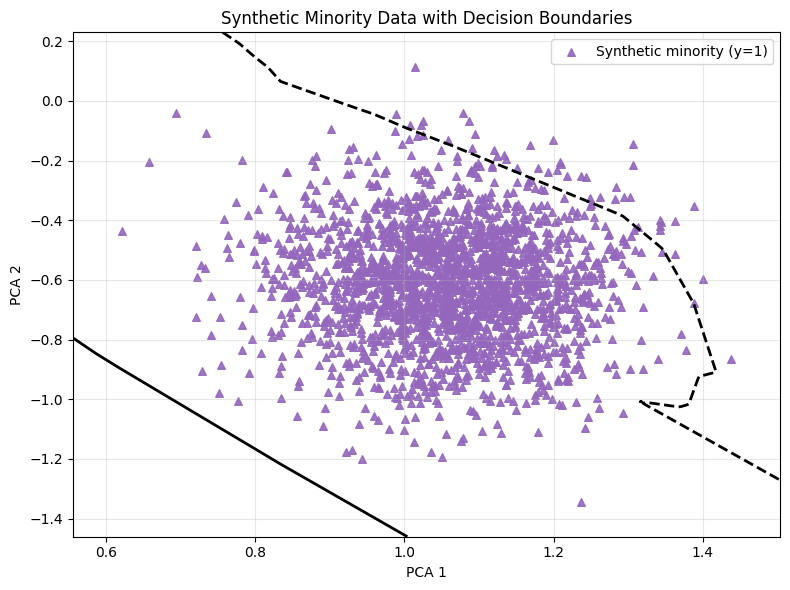

In [5]:
plot_synthetic_minority_with_boundaries(
    "training_runs/EP1000_TRJ2000_REAL3000_BIAS0.35_LS0.8-0.8_MODEgauss_nopen_TAU0.1_G202509172018_64cd83df/seed_999",
    alpha_agent,
    beta_agent,
    f1_thresh=0.5,
    grid_pad=0.08,
    grid_res=300,
    save_png=False
)

In [6]:
# --- 6D decision-boundary slices for PAMAP2 (split_pamap2_binary) ---

import os, json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from itertools import combinations
from matplotlib.lines import Line2D

from agents.ffnn_agent2 import FFNNAgent
from dataset import Dataset  # your Dataset wrapper (uses split_pamap2_binary internally)

# ---------- small utilities reused from your 2D code ----------
def _is_seed_dir(path: str) -> bool:
    return (
        os.path.isdir(path)
        and os.path.isfile(os.path.join(path, "metrics.csv"))
        and os.path.isfile(os.path.join(path, "meta.json"))
    )

def _find_seed_dir(run_dir: str) -> str:
    run_dir = os.path.abspath(run_dir.rstrip("/"))
    if _is_seed_dir(run_dir):
        return run_dir
    seed_dirs = sorted([os.path.join(run_dir, d) for d in os.listdir(run_dir) if d.startswith("seed_")])
    seed_dirs = [sd for sd in seed_dirs if _is_seed_dir(sd)]
    if len(seed_dirs) == 1:
        return seed_dirs[0]
    if len(seed_dirs) > 1:
        print(f"[info] Experiment root w/ multiple seeds; using first: {os.path.basename(seed_dirs[0])}")
        return seed_dirs[0]
    raise FileNotFoundError(f"No seed dir found under: {run_dir}")

def _read_json(path: Path) -> dict:
    try:
        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
    except Exception:
        pass
    return {}

def _detect_model_prefix(model: nn.Module) -> str:
    for k in model.state_dict().keys():
        return k.split(".", 1)[0]
    return "net"

def _remap_prefix(state_dict: dict, src_prefix: str, dst_prefix: str) -> dict:
    if src_prefix == dst_prefix:
        return state_dict
    remapped = {}
    src_head = src_prefix + "."
    dst_head = dst_prefix + "."
    for k, v in state_dict.items():
        if k.startswith(src_head):
            remapped[dst_head + k[len(src_head):]] = v
        else:
            remapped[k] = v
    return remapped

def _normalize_state_dict_to_model(state_path: Path, model: nn.Module) -> dict:
    sd = torch.load(state_path, map_location="cpu")
    if not isinstance(sd, dict):
        raise ValueError(f"Checkpoint at {state_path} is not a plain state_dict.")
    model_prefix = _detect_model_prefix(model)
    for src in ["network", "net"]:
        sd = _remap_prefix(sd, src, model_prefix)
    return sd

def _build_ffnn_config_from_meta(seed_dir: Path, default_device="cpu"):
    meta = _read_json(seed_dir / "ffnn_meta.json")
    cfg = {
        "input_size": int(meta.get("n_pca_components", 6)),  # default 6 for sensor
        "hidden_sizes": meta.get("hidden_sizes", [32, 16]),
        "output_size": meta.get("output_size", 2),
        "learning_rate": meta.get("learning_rate", 0.001),
        "batch_size": meta.get("batch_size", 32),
        "epochs": meta.get("epochs", 10),
        "type": meta.get("type", "classification"),
        "classes": meta.get("classes", [0, 1]),
        "device": default_device,
        "seed": meta.get("seed", 42),
    }
    return cfg, int(cfg["input_size"])

def _load_agent_from_ckpt(seed_dir: Path, ckpt_name: str, label: str):
    cfg, _ = _build_ffnn_config_from_meta(seed_dir, default_device="cpu")
    agent = FFNNAgent(**cfg)
    sd = _normalize_state_dict_to_model(seed_dir / ckpt_name, agent.model)
    missing, unexpected = agent.model.load_state_dict(sd, strict=False)
    if missing or unexpected:
        print(f"[warn] {label} state_dict mismatches: missing={list(missing)} unexpected={list(unexpected)}")
    else:
        print(f"[ok] {label} loaded from {ckpt_name}")
    return agent

def _load_meta(seed_dir: str | Path) -> dict:
    return _read_json(Path(seed_dir) / "meta.json")

def _reconstruct_sensor_splits_from_meta(seed_dir: str | Path, meta: dict):
    """Recreate θ_train/val/test with 6 PCA comps via Dataset (PAMAP2)."""
    seed      = int(meta.get("seed", 42))
    bias_pct  = float(meta.get("BIAS_PCT", 0.20))
    real_size = int(meta.get("REAL_DATA_SIZE", 3000))
    ds = Dataset(dataset_name="pamap2", seed=seed, device="cpu")
    Xtr, Xval, Xte, Ytr, Yval, Yte = ds.get_data_splits(
        train_size=real_size, bias_pct=bias_pct, pca_components=6
    )
    to_np = lambda t: t.detach().cpu().numpy()
    return tuple(to_np(x) for x in (Xtr, Xval, Xte, Ytr, Yval, Yte))

# ---------- main 6D slicing plot ----------
def plot_sensor_slices_6d(
    run_dir: str,
    comp_pairs=None,                 # list of (i,j); None -> all 15 pairs
    anchor="minority_mean",          # "minority_mean" | "global_mean" | ndarray shape (6,)
    grid_pts=220,
    f1_thresh=0.5,
    pad_pct=0.08,
    show_alpha=True,
    show_beta=True,
    show_test_majority=True,
    show_test_minority=True,
    overlay_synth=True,
    save_png=True
):
    seed_dir = Path(_find_seed_dir(run_dir))
    meta = _load_meta(seed_dir)

    # Load alpha/beta
    alpha = _load_agent_from_ckpt(seed_dir, "alpha_state_dict.pt", "alpha")
    beta  = _load_agent_from_ckpt(seed_dir, "best_beta_state_dict.pt", "beta") if (seed_dir/"best_beta_state_dict.pt").exists() \
            else _load_agent_from_ckpt(seed_dir, "beta_state_dict.pt", "beta")

    # Rebuild splits (6D PCA)
    Xtr, Xval, Xte, Ytr, Yval, Yte = _reconstruct_sensor_splits_from_meta(seed_dir, meta)
    D = Xtr.shape[1]
    assert D == 6, f"Expected 6 PCA comps; got {D}"

    # Anchor vector
    if isinstance(anchor, str):
        if anchor == "minority_mean":
            base = Xtr[Ytr.ravel()==1].mean(axis=0) if (Ytr==1).any() else Xtr.mean(axis=0)
        elif anchor == "global_mean":
            base = Xtr.mean(axis=0)
        else:
            raise ValueError("anchor must be 'minority_mean', 'global_mean', or ndarray")
    else:
        base = np.asarray(anchor, dtype=np.float32)
        assert base.shape == (D,), f"anchor must be shape ({D},)"

    # Pairs to slice
    if comp_pairs is None:
        comp_pairs = list(combinations(range(D), 2))  # all 15 pairs

    def p1(agent, Xnp):
        X = torch.from_numpy(Xnp.astype(np.float32))
        agent.model.eval()
        with torch.no_grad():
            logits = agent.model(X)
            return torch.softmax(logits, -1)[:,1].cpu().numpy()

    # Synthetic overlay (expects pca_0..pca_5,target)
    synth_df = None
    if overlay_synth and (seed_dir/"best_synthetic.csv").exists():
        try:
            sdf = pd.read_csv(seed_dir/"best_synthetic.csv")
            need = [f"pca_{k}" for k in range(D)] + ["target"]
            if all(c in sdf.columns for c in need):
                synth_df = sdf.copy()
        except Exception as e:
            print(f"[warn] failed reading best_synthetic.csv: {e}")

    # Build ranges from TRAIN+TEST on each 2D pair
    all_real = np.vstack([Xtr, Xte])

    saved_pngs = []
    for (i, j) in comp_pairs:
        # 2D limits (robust)
        sub = all_real[:, [i, j]]
        lo = np.percentile(sub, 1, axis=0); hi = np.percentile(sub, 99, axis=0)
        dx, dy = hi - lo
        lo -= pad_pct * np.array([dx, dy]); hi += pad_pct * np.array([dx, dy])

        xi = np.linspace(lo[0], hi[0], grid_pts)
        xj = np.linspace(lo[1], hi[1], grid_pts)
        XI, XJ = np.meshgrid(xi, xj)

        # Full-D grid from anchor + (i,j) replacements
        G = np.tile(base, (grid_pts*grid_pts, 1))
        G[:, i] = XI.ravel(); G[:, j] = XJ.ravel()

        P_a = p1(alpha, G) if show_alpha else None
        P_b = p1(beta,  G) if show_beta  else None
        Zb  = (P_b if P_b is not None else P_a).reshape(grid_pts, grid_pts)
        fig, ax = plt.subplots(figsize=(7.2, 6.2))

        # filled probs (β if available)
        im = ax.contourf(XI, XJ, Zb, levels=24, alpha=0.35)

        # 0.5 contours
        if P_a is not None:
            ax.contour(XI, XJ, P_a.reshape(grid_pts,grid_pts), levels=[f1_thresh],
                       linewidths=1.6, linestyles="--", colors="black")
        if P_b is not None:
            ax.contour(XI, XJ, P_b.reshape(grid_pts,grid_pts), levels=[f1_thresh],
                       linewidths=1.6, linestyles="-", colors="black")

        # TEST scatter
        if show_test_majority:
            ax.scatter(Xte[Yte.ravel()==0, i], Xte[Yte.ravel()==0, j], s=10, alpha=0.65, label="Test 0")
        if show_test_minority:
            ax.scatter(Xte[Yte.ravel()==1, i], Xte[Yte.ravel()==1, j], s=14, alpha=0.85, marker="^", label="Test 1")

        # SYNTH overlay (minority)
        if synth_df is not None:
            xs = synth_df[[f"pca_{i}", f"pca_{j}"]].to_numpy()
            ys = synth_df["target"].to_numpy().astype(int)
            if (ys == 1).any():
                ax.scatter(xs[ys==1,0], xs[ys==1,1], s=18, alpha=0.95, marker="x", label="Synth 1", zorder=5)

        # cosmetics
        proxy_alpha = Line2D([0],[0], color="black", lw=1.6, ls="--", label="α boundary")
        proxy_beta  = Line2D([0],[0], color="black", lw=1.6, ls="-",  label="β boundary")
        handles, labels = ax.get_legend_handles_labels()
        handles = [proxy_alpha, proxy_beta] + handles
        labels  = [h.get_label() for h in [proxy_alpha, proxy_beta]] + labels

        ax.set_xlabel(f"PCA {i}")
        ax.set_ylabel(f"PCA {j}")
        exp_name  = seed_dir.parent.name
        seed_name = seed_dir.name
        ax.set_title(f"PAMAP2 — Decision slice ({i},{j})\nAnchor: {anchor} | Run: {exp_name}/{seed_name}")
        ax.legend(loc="best", fontsize=9)
        ax.grid(alpha=0.25)
        plt.tight_layout()

        if save_png:
            out = seed_dir / f"decision_slice_pca{i}_pca{j}.png"
            plt.savefig(out, dpi=170); saved_pngs.append(str(out))
        plt.show()

    if saved_pngs:
        print("[info] saved:", *saved_pngs, sep="\n - ")


FFNN Using device: cpu
[ok] alpha loaded from alpha_state_dict.pt
FFNN Using device: cpu
[ok] beta loaded from best_beta_state_dict.pt


/home/epigou/cs_9170_project/dataset.py:281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.sort_values(["subject_id", "timestamp"]).groupby("subject_id", group_keys=False).apply(


[TRAIN] size=483, rope=24 (4.97%), class0=459, class1=24
[VAL] size=236, rope=11 (4.66%), class0=225, class1=11
[TEST] size=431, rope=166 (38.52%), class0=265, class1=166
PCA comps: 6 | Features in: 14 | Classes: [np.int64(0), np.int64(1)]


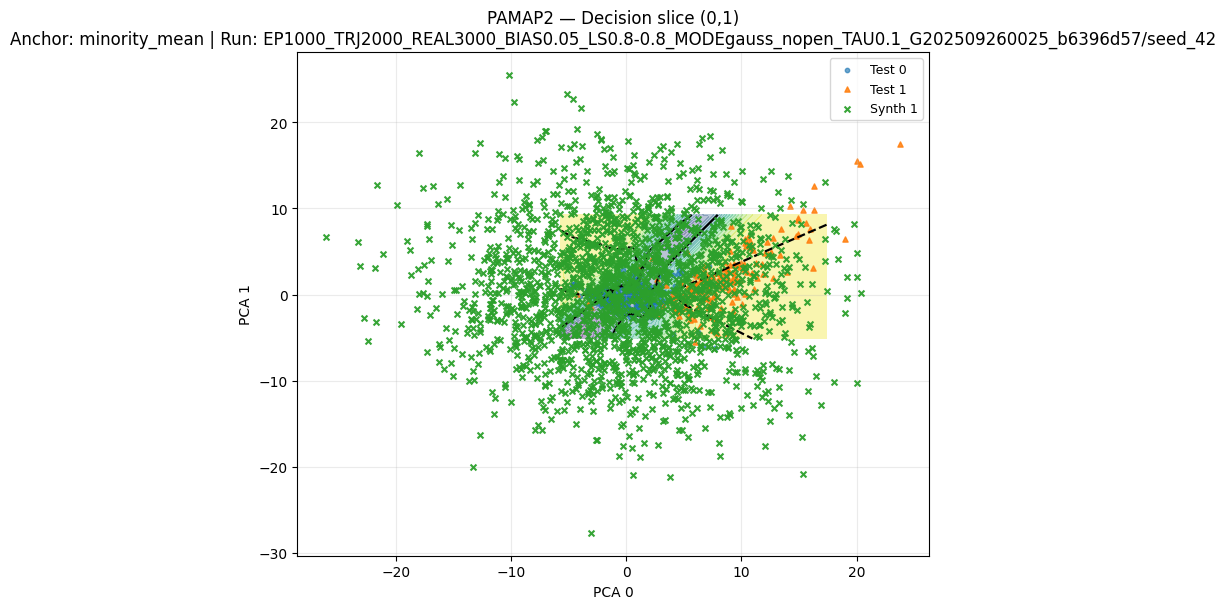

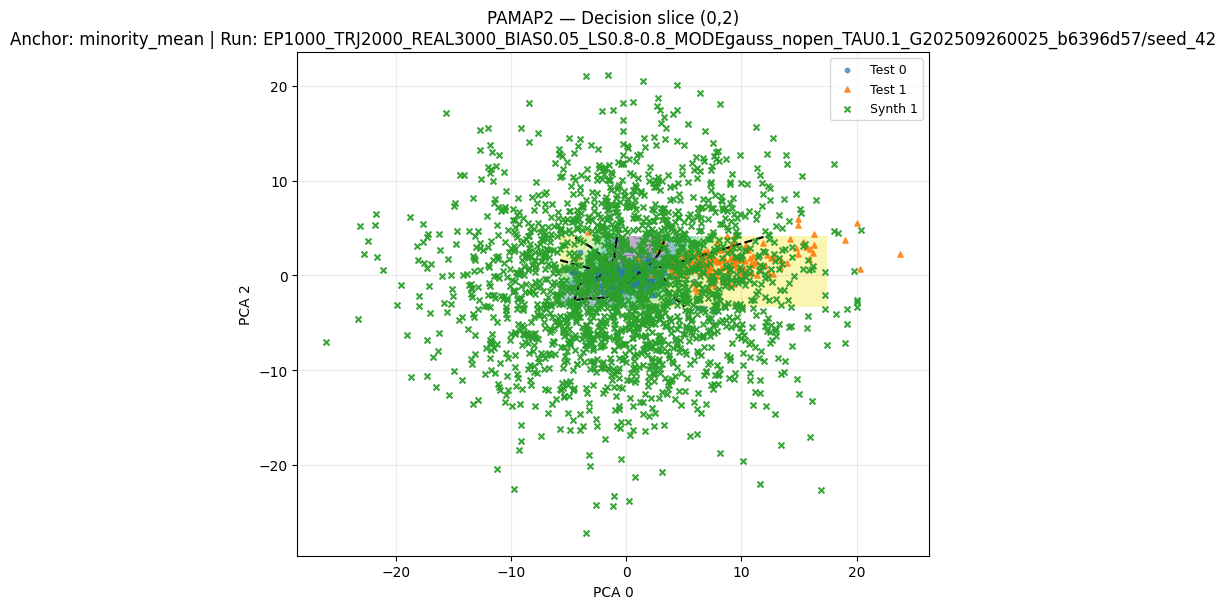

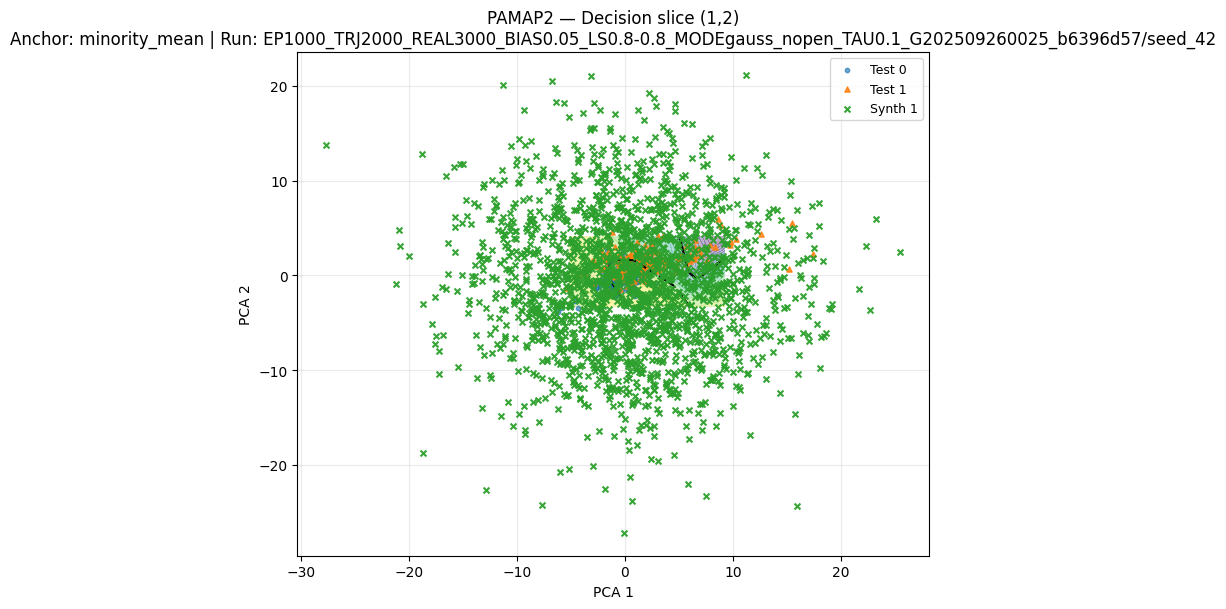

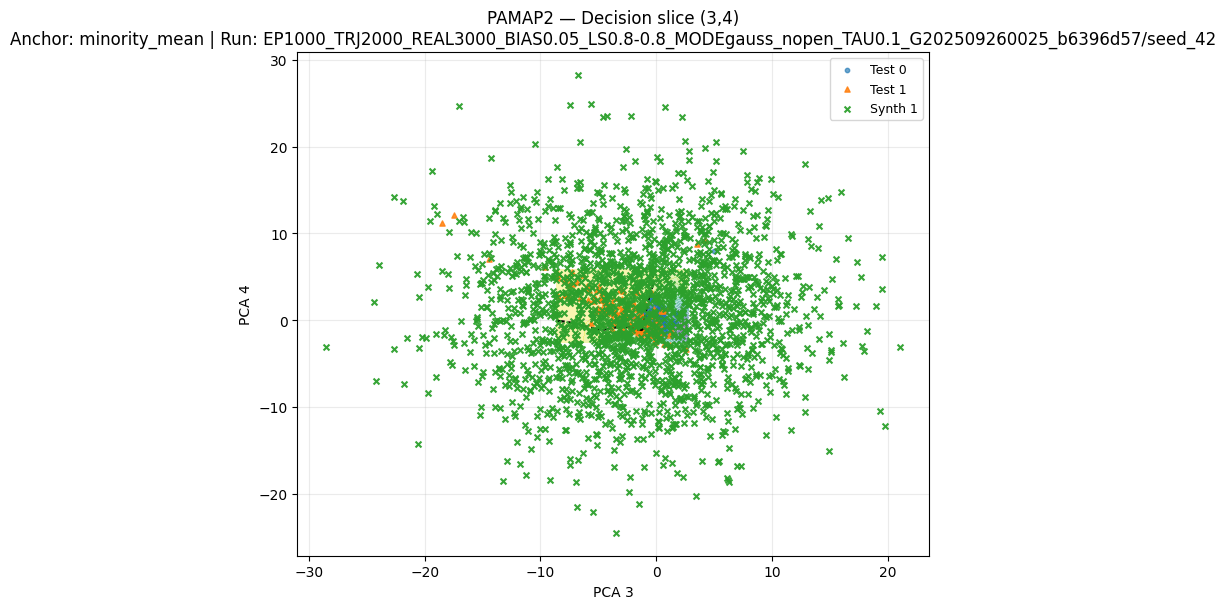

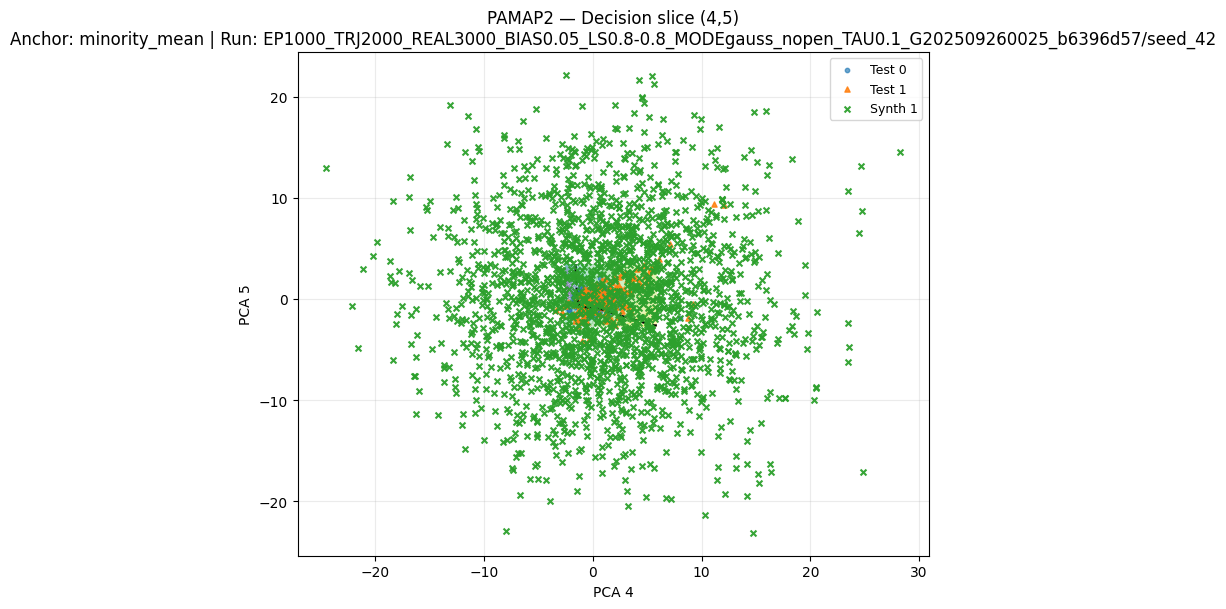

In [7]:
# Example: plot a few informative pairs first
plot_sensor_slices_6d(
    run_dir="training_runs/EP1000_TRJ2000_REAL3000_BIAS0.05_LS0.8-0.8_MODEgauss_nopen_TAU0.1_G202509260025_b6396d57/seed_42",
    comp_pairs=[(0,1), (0,2), (1,2), (3,4), (4,5)],   # or None for all 15
    anchor="minority_mean",    # also try "global_mean"
    grid_pts=220,
    overlay_synth=True,
    save_png=False
)
